<a href="https://colab.research.google.com/github/microsoft/qlib/blob/main/examples/workflow_by_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# 1. Qlib 소스코드 다운로드 (스크립트 사용 위함)
!git clone https://github.com/microsoft/qlib.git
# 2. 패키지 설치
!cd qlib && pip install .
!pip install plotly

Cloning into 'qlib'...
remote: Enumerating objects: 19493, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 19493 (delta 10), reused 3 (delta 3), pack-reused 19466 (from 3)
Receiving objects: 100% (19493/19493), 17.51 MiB | 4.79 MiB/s, done.
Resolving deltas: 100% (14057/14057), done.
Processing /content/qlib
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached setuptools_scm-9.2.2-py3-none-any.whl.metadata (7.7 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━

In [5]:
import qlib
# 1. 데이터 저장 경로 설정
provider_uri = "~/.qlib/qlib_data/us_data"
# 2. 데이터 다운로드
!python qlib/scripts/get_data.py qlib_data --target_dir {provider_uri} --region us

2026-01-19 06:09:54.613 | WARNING  | qlib.tests.data:download:62 - The data for the example is collected from Yahoo Finance. Please be aware that the quality of the data might not be perfect. (You can refer to the original data source: https://finance.yahoo.com/lookup.)
2026-01-19 06:09:54.613 | INFO     | qlib.tests.data:download:65 - 20260119060953_qlib_data_us_1d_latest.zip downloading......
450095104it [01:04, 7029917.39it/s]                    
2026-01-19 06:10:58.640 | WARNING  | qlib.tests.data:_unzip:124 - will delete the old qlib data directory(features, instruments, calendars, features_cache, dataset_cache): /root/.qlib/qlib_data/us_data
2026-01-19 06:10:58.640 | INFO     | qlib.tests.data:_unzip:128 - /root/.qlib/qlib_data/us_data/20260119060953_qlib_data_us_1d_latest.zip unzipping......
100% 71959/71959 [00:15<00:00, 4746.43it/s]


In [6]:
from qlib.constant import REG_CN, REG_US
# 사용하는 데이터에 따라 경로와 Region을 맞춰주세요!
# US 사용 시: provider_uri="~/.qlib/qlib_data/us_data", region=REG_US
provider_uri = "~/.qlib/qlib_data/us_data"  # 예: US 선택 시
qlib.init(provider_uri=provider_uri, region=REG_US)
print(f"Qlib Init Success! path={provider_uri}")

[347:MainThread](2026-01-19 06:11:21,614) INFO - qlib.Initialization - [config.py:452] - default_conf: client.
[347:MainThread](2026-01-19 06:11:23,897) INFO - qlib.Initialization - [__init__.py:82] - qlib successfully initialized based on client settings.
[347:MainThread](2026-01-19 06:11:23,898) INFO - qlib.Initialization - [__init__.py:84] - data_path={'__DEFAULT_FREQ': PosixPath('/root/.qlib/qlib_data/us_data')}


Qlib Init Success! path=~/.qlib/qlib_data/us_data


In [7]:
conf_str = """
qlib_init:
    provider_uri: ~/.qlib/qlib_data/us_data
    region: us
market: &market sp500
benchmark: &benchmark ^GSPC
data_handler_config: &data_handler_config
    start_time: 2010-01-01
    end_time: 2020-08-01
    fit_start_time: 2010-01-01
    fit_end_time: 2017-12-31
    instruments: *market
    infer_processors:
        - class: RobustZScoreNorm
          kwargs:
              fields_group: feature
              clip_outlier: true
        - class: Fillna
          kwargs:
              fields_group: feature
    learn_processors:
        - class: DropnaLabel
        - class: CSRankNorm
          kwargs:
              fields_group: label
    label: ["Ref($close, -2) / Ref($close, -1) - 1"] # 2일 뒤 수익률 예측
task:
    model:
        class: LGBModel
        module_path: qlib.contrib.model.gbdt
        kwargs:
            loss: mse
            colsample_bytree: 0.8879
            learning_rate: 0.0421
            subsample: 0.8789
            lambda_l1: 205.6999
            lambda_l2: 580.9768
            max_depth: 15
            num_leaves: 210
            num_threads: 20
    dataset:
        class: DatasetH
        module_path: qlib.data.dataset
        kwargs:
            handler:
                class: Alpha158
                module_path: qlib.contrib.data.handler
                kwargs: *data_handler_config
            segments:
                train: [2010-01-01, 2017-12-31] # 8년 학습
                valid: [2018-01-01, 2018-12-31] # 1년 검증
                test: [2019-01-01, 2020-08-01]  # 1.5년 테스트 (데이터 보장 구간)
    record:
        - class: SignalRecord
          module_path: qlib.workflow.record_temp
          kwargs:
            model: <MODEL>
            dataset: <DATASET>
        - class: SigAnaRecord
          module_path: qlib.workflow.record_temp
          kwargs:
            ana_long_short: False
            ann_scaler: 252
"""
# YAML 파일로 저장
with open('workflow_config.yaml', 'w') as f:
    f.write(conf_str)

[347:MainThread](2026-01-19 06:19:27,813) INFO - qlib.Initialization - [config.py:452] - default_conf: client.
[347:MainThread](2026-01-19 06:19:27,814) WARNING - qlib.Initialization - [config.py:459] - Unrecognized config experiment_name
[347:MainThread](2026-01-19 06:19:27,820) INFO - qlib.Initialization - [__init__.py:82] - qlib successfully initialized based on client settings.
[347:MainThread](2026-01-19 06:19:27,822) INFO - qlib.Initialization - [__init__.py:84] - data_path={'__DEFAULT_FREQ': PosixPath('/root/.qlib/qlib_data/us_data')}
[347:MainThread](2026-01-19 06:21:45,976) INFO - qlib.timer - [log.py:127] - Time cost: 138.143s | Loading data Done
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1233: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
[347:MainThread](2026-01-19 06:21:55,607) INFO - qlib.timer - [log.py:127] - Time cost: 8.851s | RobustZScoreNorm Done
[347:MainThread](2026-01-19 06:21:5

ModuleNotFoundError. CatBoostModel are skipped. (optional: maybe installing CatBoostModel can fix it.)


/usr/local/lib/python3.12/dist-packages/mlflow/tracking/_tracking_service/utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)
[347:MainThread](2026-01-19 06:22:03,887) WARNING - qlib.workflow - [expm.py:231] - No valid experiment found. Create a new experiment with name colab_experiment.
[347:MainThread](2026-01-19 06:22:03,892) INFO - qlib.workflow - [exp.py:258] - Experiment 673518329604922833 starts running ...


📊 데이터셋 검증 중...
✅ Test 데이터 로드 성공: 198487 rows
DATA SAMPLE:
                                                      label
                      Ref($close, -2) / Ref($close, -1) - 1
datetime   instrument                                      
2019-01-02 A                                       0.034613
           AAL                                     0.065868
           AAP                                    -0.024808
           AAPL                                    0.042689
           ABBV                                    0.032217


[347:MainThread](2026-01-19 06:22:04,090) INFO - qlib.workflow - [recorder.py:345] - Recorder 805d48b86e8a48c0b1f679415ff64c6e starts running under Experiment 673518329604922833 ...
[347:MainThread](2026-01-19 06:22:04,097) INFO - qlib.workflow - [recorder.py:378] - Fail to log the uncommitted code of $CWD(/content) when run git diff.
[347:MainThread](2026-01-19 06:22:04,104) INFO - qlib.workflow - [recorder.py:378] - Fail to log the uncommitted code of $CWD(/content) when run git status.
[347:MainThread](2026-01-19 06:22:04,108) INFO - qlib.workflow - [recorder.py:378] - Fail to log the uncommitted code of $CWD(/content) when run git diff --cached.


🤖 모델 학습 시작...
Training until validation scores don't improve for 50 rounds
[20]	train's l2: 0.995072	valid's l2: 0.997675
[40]	train's l2: 0.992659	valid's l2: 0.997873
[60]	train's l2: 0.990499	valid's l2: 0.998052
Early stopping, best iteration is:
[15]	train's l2: 0.995666	valid's l2: 0.997607
✅ 모델 학습 완료!
🔮 예측 수행 중...
📊 Mean IC: 0.0138
📊 ICIR: 0.1070


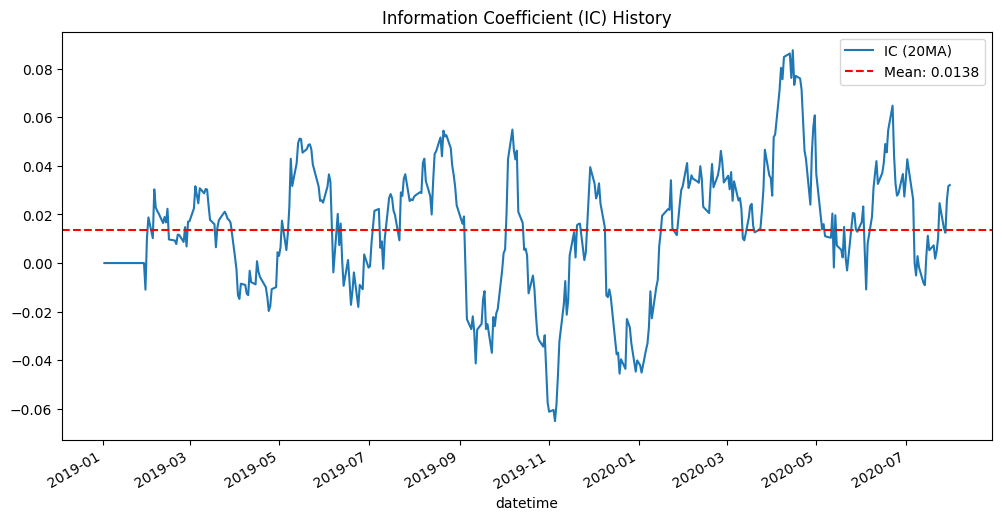

[347:MainThread](2026-01-19 06:23:27,695) INFO - qlib.timer - [log.py:127] - Time cost: 0.000s | waiting `async_log` Done


In [8]:
import qlib
import yaml
import pandas as pd
from qlib.utils import init_instance_by_config
from qlib.workflow import R
# 1. 설정 로드
with open('workflow_config.yaml', 'r') as f:
    config = yaml.safe_load(f)
# 2. Qlib 초기화
# ⚠️ 중요: 만약 에러("Qlib already initialized")가 나면, 상단 메뉴 [런타임] > [세션 다시 시작]을 누르고 다시 실행하세요.
# Qlib은 한 번 켜지면 설정을 바꾸기 어렵습니다. 아예 껏다 켜는 게 가장 빠릅니다.
try:
    qlib.init(provider_uri="~/.qlib/qlib_data/us_data", region="us", experiment_name="colab_experiment")
except Exception:
    print("⚠️ Qlib이 이미 초기화되었습니다. 설정을 바꾸려면 [런타임] > [세션 다시 시작] 해주세요!")
# 3. 데이터셋 & 모델 초기화
dataset_config = config['task']['dataset']
model_config = config['task']['model']
dataset = init_instance_by_config(dataset_config)
model = init_instance_by_config(model_config)
# [디버그] 데이터가 제대로 로드되었는지 확인
print("📊 데이터셋 검증 중...")
try:
    # Test 구간 데이터 샘플 확인
    example_test = dataset.prepare("test", col_set=["label"])
    if len(example_test) == 0:
        print("⚠️ 경고: Test 데이터가 비어있습니다! 날짜 설정을 확인하세요.")
    else:
        print(f"✅ Test 데이터 로드 성공: {len(example_test)} rows")
        print(f"DATA SAMPLE:\n{example_test.head()}")
        # Label(정답)이 전부 NaN인지 체크
        if example_test.iloc[:, 0].isnull().all():
            print("❌ 에러: Label(정답) 데이터가 전부 NaN입니다.")
except Exception as e:
    print(f"⚠️ 데이터 로드 중 에러 발생: {e}")
# 4. 실험 시작 및 학습
# ... (이하 동일)
with R.start(experiment_name="colab_experiment"):
    print("🤖 모델 학습 시작...")
    model.fit(dataset)
    print("✅ 모델 학습 완료!")

    # 5. 예측 및 결과 저장
    print("🔮 예측 수행 중...")
    pred_df = model.predict(dataset)

    # Series인 경우 DataFrame으로 변환 (KeyError 방지)
    if isinstance(pred_df, pd.Series):
        pred_df = pred_df.to_frame('score')
    else:
        pred_df.columns = ['score']

    R.save_objects(pred=pred_df)

    # 6. 간단한 IC 분석 (Manual Analysis)
    # Test 데이터의 Label(수익률) 가져오기
    test_data = dataset.prepare("test", col_set=["label"])

    # 예측값과 합치기
    analysis_df = pred_df.copy()

    # test_data 처리 (DataFrame/Tuple/Series 대응)
    if isinstance(test_data, pd.DataFrame):
        analysis_df['label'] = test_data.iloc[:, 0]
    elif isinstance(test_data, tuple):
        analysis_df['label'] = test_data[1].iloc[:, 0]
    else:
        analysis_df['label'] = test_data

    analysis_df = analysis_df.dropna()

    # IC 계산 (Pearson Correlation)
    # datetime 레벨로 그룹화하여 상관계수 계산
    ic = analysis_df.groupby('datetime').apply(lambda x: x['score'].corr(x['label']))

    # 만약 IC가 DataFrame으로 나오면 Series로 변환
    if isinstance(ic, pd.DataFrame):
        ic = ic.iloc[:, 0]

    # IC 결과 출력 (Scalar 변환 안전장치)
    ic_mean = ic.mean()
    ic_std = ic.std()

    # Series/Numpy array인 경우 스칼라로 변환
    if hasattr(ic_mean, 'item'):
        ic_mean = ic_mean.item()
    if hasattr(ic_std, 'item'):
        ic_std = ic_std.item()

    print(f"📊 Mean IC: {ic_mean:.4f}")
    print(f"📊 ICIR: {ic_mean / (ic_std + 1e-9):.4f}")

    # 그래프 저장
    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12, 6))
        # fillna를 통해 데이터 공백 처리
        ic.rolling(20).mean().fillna(0).plot(label='IC (20MA)')
        plt.axhline(ic_mean, color='r', linestyle='--', label=f'Mean: {ic_mean:.4f}')
        plt.legend()
        plt.title("Information Coefficient (IC) History")
        plt.show()
    except Exception as e:
        print(f"Graph Error: {e}")
        pass

🔥 GPU 감지됨: Tesla T4


[347:MainThread](2026-01-19 06:24:01,492) INFO - qlib.TransformerModel - [pytorch_transformer.py:63] - Naive Transformer:
batch_size : 2048
device : cuda:0


📊 감지된 순수 Feature 개수: 158
🚀 Transformer 모델 학습 시작... (잠시만 기다려주세요)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(
[347:MainThread](2026-01-19 06:24:07,212) WARNING - qlib.workflow - [expm.py:231] - No valid experiment found. Create a new experiment with name colab_transformer.
[347:MainThread](2026-01-19 06:24:07,219) INFO - qlib.workflow - [exp.py:258] - Experiment 460633514739690377 starts running ...
[347:MainThread](2026-01-19 06:24:07,231) INFO - qlib.workflow - [recorder.py:345] - Recorder 5c290fd98e174db5ac92484ea1a2a4eb starts running under Experiment 460633514739690377 ...
[347:MainThread](2026-01-19 06:24:07,238) INFO - qlib.workflow - [recorder.py:378] - Fail to log the uncommitted code of $CWD(/content) when run git diff.
[347:MainThread](2026-01-19 06:24:07,249) INFO - qlib.workflow - [recorder.py:378] - Fail 

✅ 학습 완료!
🔮 예측 수행 중...

[Debug] 예측값 통계:
count    198487.000000
mean         -0.006015
std           0.022991
min          -0.117333
25%          -0.021163
50%          -0.004468
75%           0.010658
max           0.074659
Name: score, dtype: float64
📊 Transformer Mean IC: 0.0040


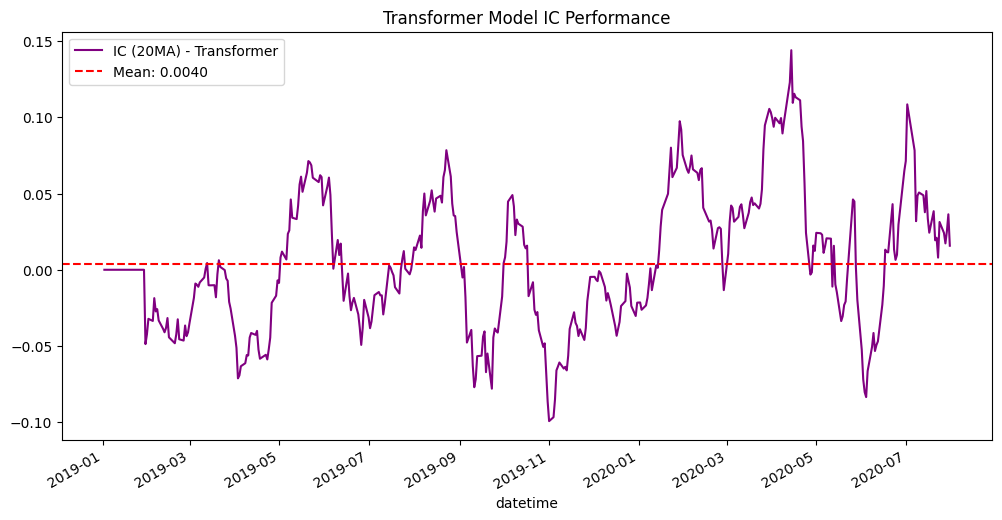

[347:MainThread](2026-01-19 06:25:55,816) INFO - qlib.timer - [log.py:127] - Time cost: 0.000s | waiting `async_log` Done


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
# 0. 데이터셋의 Feature 개수 확인 및 GPU 체크
import torch
# GPU 사용 가능 여부 확인
if torch.cuda.is_available():
    print(f"🔥 GPU 감지됨: {torch.cuda.get_device_name(0)}")
    device_arg = 0 # 0번 GPU
else:
    print("⚠️ GPU가 감지되지 않았습니다! [런타임] > [런타임 유형 변경]에서 T4 GPU를 선택하세요.")
    device_arg = -1 # CPU
# 주의: Label(정답) 컬럼을 제외하고 순수 Feature(문제) 개수만 세야 합니다.
d_feat = dataset.prepare("train", col_set=["feature"]).shape[1]
print(f"📊 감지된 순수 Feature 개수: {d_feat}")
# 1. 모델 설정을 Transformer로 교체
config['task']['model'] = {
    'class': 'TransformerModel',
    'module_path': 'qlib.contrib.model.pytorch_transformer',
    'kwargs': {
        'd_feat': d_feat,
        'd_model': 64,
        'nhead': 8,
        'n_layers': 2,
        'dropout': 0.1,
        'seed': 42,
        'GPU': device_arg, # 감지된 GPU ID 할당
        'lr': 1e-4,
        'n_epochs': 40,
        'batch_size': 2048,
        'metric': 'loss'
    }
}
print("🚀 Transformer 모델 학습 시작... (잠시만 기다려주세요)")
# 2. 모델 재 초기화 및 학습
model = init_instance_by_config(config['task']['model'])
with R.start(experiment_name="colab_transformer"):
    # 학습
    model.fit(dataset)
    print("✅ 학습 완료!")

    # 예측
    print("🔮 예측 수행 중...")
    pred_df = model.predict(dataset)

    # DataFrame 변환 (안전장치)
    if isinstance(pred_df, pd.Series):
        pred_df = pred_df.to_frame('score')
    else:
        pred_df.columns = ['score']

    # 디버깅: 예측값 분포 확인 (만약 std가 0이면 학습 실패)
    print("\n[Debug] 예측값 통계:")
    print(pred_df['score'].describe())

    R.save_objects(pred=pred_df)

    # 3. 결과 분석
    # ... (이하 동일: IC 계산 및 시각화)
    test_data = dataset.prepare("test", col_set=["label"])

    analysis_df = pred_df.copy()
    if isinstance(test_data, pd.DataFrame):
        analysis_df['label'] = test_data.iloc[:, 0]
    elif isinstance(test_data, tuple):
        analysis_df['label'] = test_data[1].iloc[:, 0]
    else:
        analysis_df['label'] = test_data

    analysis_df = analysis_df.dropna()

    # IC 계산
    ic = analysis_df.groupby('datetime').apply(lambda x: x['score'].corr(x['label']))

    if isinstance(ic, pd.DataFrame):
        ic = ic.iloc[:, 0]

    ic_mean = ic.mean()
    if hasattr(ic_mean, 'item'): ic_mean = ic_mean.item()

    print(f"📊 Transformer Mean IC: {ic_mean:.4f}")

    # 그래프
    plt.figure(figsize=(12, 6))
    ic.rolling(20).mean().fillna(0).plot(label='IC (20MA) - Transformer', color='purple')
    plt.axhline(ic_mean, color='r', linestyle='--', label=f'Mean: {ic_mean:.4f}')
    plt.legend()
    plt.title("Transformer Model IC Performance")
    plt.show()

In [10]:
import joblib
# 1. 모델 추출 (Qlib Wrapper 벗기기)
# LightGBM의 경우
if hasattr(model, 'model'):
    raw_model = model.model
else:
    raw_model = model # Transformer 등은 그대로 사용
# 2. 앱 호환 메타데이터 포장
# 앱은 이 딕셔너리 구조를 기대합니다.
export_package = {
    "model": raw_model,
    "feature_cols": dataset_config['kwargs']['handler']['kwargs']['infer_processors'][0]['kwargs']['fields_group'], # or simply 'feature'
    "feature_level": "Pro (Alpha158)",
    "horizon": "1d",
    "universe": "S&P 500",
    "description": "Colab에서 학습된 Qlib 모델"
}
# 3. 파일 저장 (.pkl)
save_path = "colab_model_sp500.pkl"
joblib.dump(export_package, save_path)
print(f"✅ 모델 저장 완료: {save_path}")
# 4. 내 컴퓨터로 다운로드 (Colab 기능)
from google.colab import files
files.download(save_path)

✅ 모델 저장 완료: colab_model_sp500.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>